1.IMPORT Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import resample
import joblib
from collections import Counter

2 Visualization Settings

In [2]:
sns.set_style("whitegrid")
sns.set_palette("Set2") 
plt.rcParams["figure.figsize"] = (8,5)

3 Load Dataset

In [3]:
df = pd.read_csv("Road Accident Data.csv")

df.head()

,Accident_Index,Accident Date,Month,Day_of_Week,Year,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200901BS70001,1/1/2021,Jan,Thursday,2021,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,200901BS70002,1/5/2021,Jan,Monday,2021,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,200901BS70003,1/4/2021,Jan,Sunday,2021,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,200901BS70004,1/5/2021,Jan,Monday,2021,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,8:10,Urban,Other,Motorcycle over 500cc
4,200901BS70005,1/6/2021,Jan,Tuesday,2021,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


In [4]:
df.rename(columns={'Accident_Severity': 'severity'}, inplace=True)

4 Dataset Overview

In [5]:
df.shape

(307973, 23)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Accident_Index              307973 non-null  str    
 1   Accident Date               307973 non-null  str    
 2   Month                       307973 non-null  str    
 3   Day_of_Week                 307973 non-null  str    
 4   Year                        307973 non-null  int64  
 5   Junction_Control            307973 non-null  str    
 6   Junction_Detail             307973 non-null  str    
 7   severity                    307973 non-null  str    
 8   Latitude                    307973 non-null  float64
 9   Light_Conditions            307973 non-null  str    
 10  Local_Authority_(District)  307973 non-null  str    
 11  Carriageway_Hazards         5424 non-null    str    
 12  Longitude                   307973 non-null  float64
 13  Number_of_Casualties     

5 Remove Unnecessary Columns

In [7]:
df = df.drop(columns=[
    "Accident_Index",
    "Accident Date",
    "Latitude",
    "Longitude"
])

6 Check Missing Value

In [8]:
df.isnull().sum()

Month                              0
Day_of_Week                        0
Year                               0
Junction_Control                   0
Junction_Detail                    0
severity                           0
Light_Conditions                   0
Local_Authority_(District)         0
Carriageway_Hazards           302549
Number_of_Casualties               0
Number_of_Vehicles                 0
Police_Force                       0
Road_Surface_Conditions          317
Road_Type                       1534
Speed_limit                        0
Time                              17
Urban_or_Rural_Area                0
Weather_Conditions              6057
Vehicle_Type                       0
dtype: int64

7 Handle Missing Values

In [9]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns


for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())


for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\HP\AppData\Local\Temp\ipykernel_7924\968469924.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


8 Remove Duplicate Rows

In [10]:
df = df.drop_duplicates()

9 Encode Categorical Variables

In [11]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

10 Exploratory Data Analysis


Accident Severity Distribution

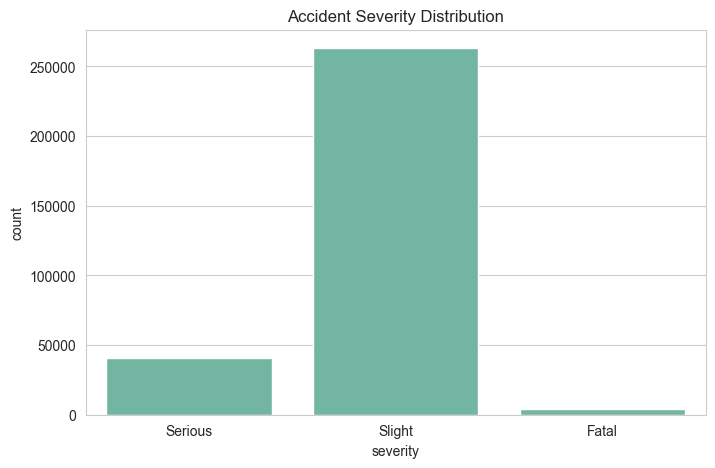

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="severity", data=df)

plt.title("Accident Severity Distribution")
plt.show()

Weather Condition Impact

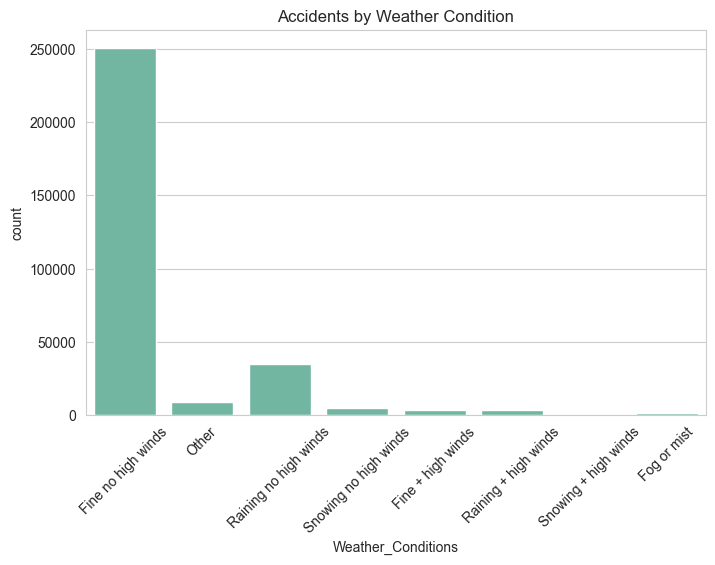

In [13]:
sns.countplot(x="Weather_Conditions", data=df)

plt.xticks(rotation=45)

plt.title("Accidents by Weather Condition")

plt.show()

Road Type Impact

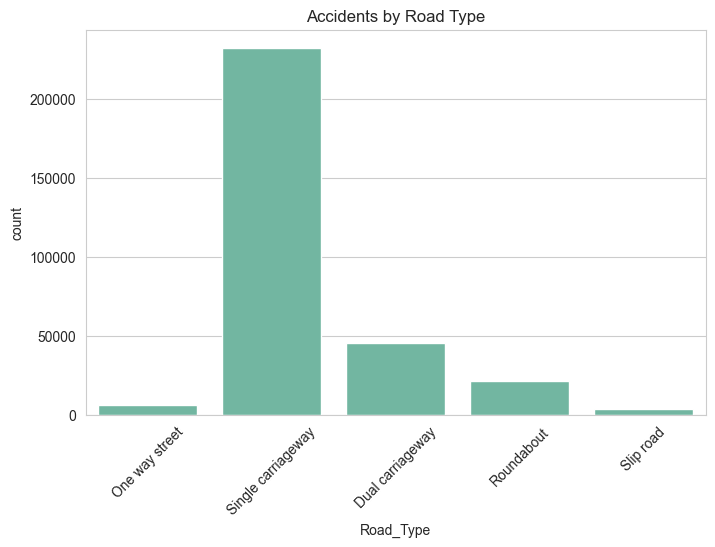

In [14]:
sns.countplot(x="Road_Type", data=df)

plt.xticks(rotation=45)

plt.title("Accidents by Road Type")

plt.show()

11 Correlation Heatmap

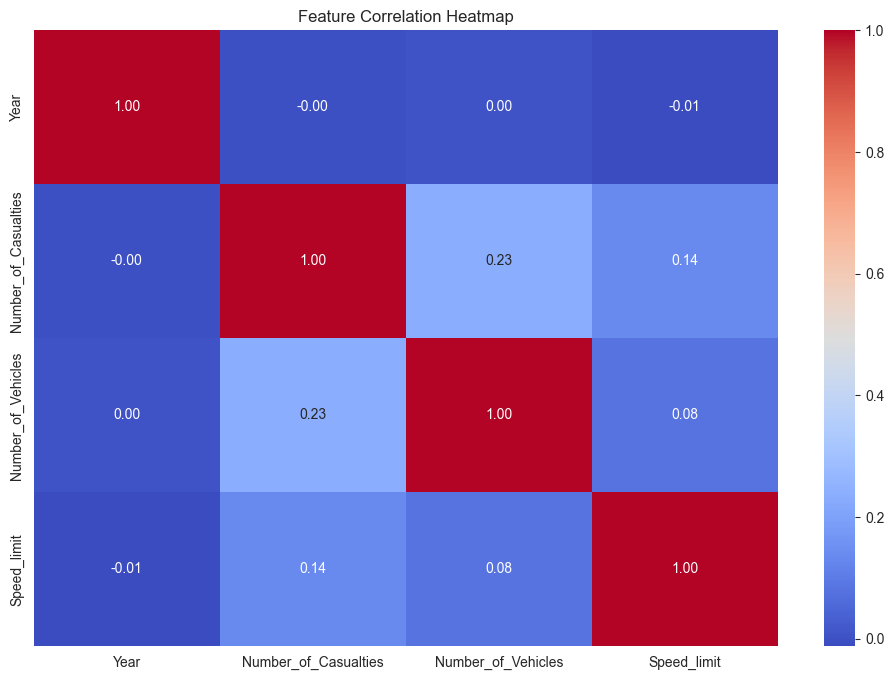

In [15]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))

sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=True, fmt=".2f")

plt.title("Feature Correlation Heatmap")

plt.show()

12 Prepare Data

In [16]:
X = df.drop("severity", axis=1)
y = df["severity"]

13 Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

14 Logistic Regression Model

In [18]:
# -------------------------------
# Point 14 : Logistic Regression (FAST VERSION)
# -------------------------------

# Reduce dataset size
df_sample = df.sample(30000, random_state=42)

# Remove very large categorical columns (they create hundreds of dummy variables)
df_sample = df_sample.drop(columns=["Local_Authority_(District)", "Time"], errors="ignore")

# Separate target
y = df_sample["severity"]

# Features
X = df_sample.drop("severity", axis=1)

# Encode categorical columns
X = pd.get_dummies(X, drop_first=True)

# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=500)

# Train
log_model.fit(X_train, y_train)

# Predict
log_pred = log_model.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

Accuracy: 0.851
              precision    recall  f1-score   support

       Fatal       0.00      0.00      0.00        88
     Serious       0.00      0.00      0.00       806
      Slight       0.85      1.00      0.92      5106

    accuracy                           0.85      6000
   macro avg       0.28      0.33      0.31      6000
weighted avg       0.72      0.85      0.78      6000



c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs

knn model

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create KNN model (weak model)
knn = KNeighborsClassifier(n_neighbors=1)

# Train the model
knn.fit(X_train, y_train)

# Predict on test data
y_pred_knn = knn.predict(X_test)

# Calculate accuracy
knn_acc = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.7611666666666667


15 Decision Tree Model

In [20]:
# -------------------------------
# Point 15 : Decision Tree Model
# -------------------------------

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
dt_model = DecisionTreeClassifier(
    max_depth=10,        # prevents overfitting
    random_state=42
)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.8416666666666667

Classification Report:

              precision    recall  f1-score   support

       Fatal       0.00      0.00      0.00        88
     Serious       0.26      0.04      0.07       806
      Slight       0.85      0.98      0.91      5106

    accuracy                           0.84      6000
   macro avg       0.37      0.34      0.33      6000
weighted avg       0.76      0.84      0.79      6000



16 – Random Forest Model

In [21]:
# -------------------------------
# Point 16 : Random Forest Model
# -------------------------------

from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.6708333333333333

Classification Report:

              precision    recall  f1-score   support

       Fatal       0.04      0.23      0.06        88
     Serious       0.20      0.30      0.24       806
      Slight       0.88      0.74      0.80      5106

    accuracy                           0.67      6000
   macro avg       0.37      0.42      0.37      6000
weighted avg       0.78      0.67      0.72      6000



17 – Model Accuracy Comparison

In [22]:
# -------------------------------
# Point 17 : Model Comparison
# -------------------------------

log_acc = accuracy_score(y_test, log_pred)
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)
knn_acc = accuracy_score(y_test, y_pred_knn)   

import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "KNN"],
    "Accuracy": [log_acc, dt_acc, rf_acc, knn_acc]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.851000
1        Decision Tree  0.841667
2        Random Forest  0.670833
3                  KNN  0.761167


18 – Accuracy Graph

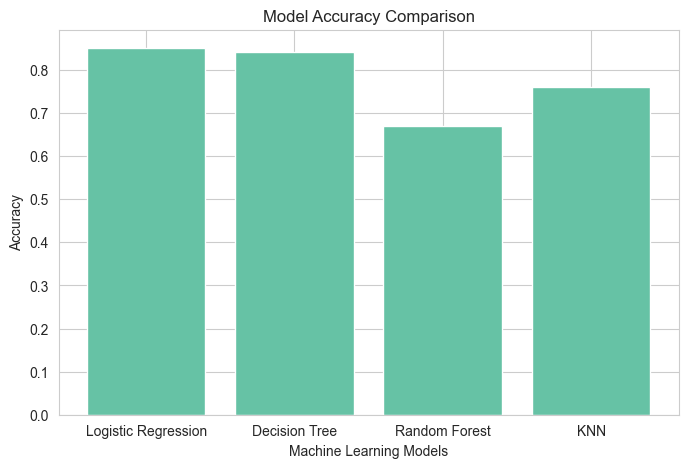

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Machine Learning Models")

plt.show()

Confusion Matrix

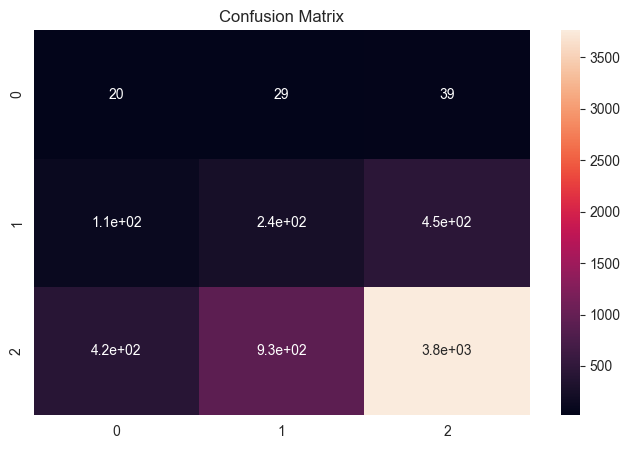

In [24]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True)

plt.title("Confusion Matrix")

plt.show()

19 Classification Report

In [25]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

       Fatal       0.04      0.23      0.06        88
     Serious       0.20      0.30      0.24       806
      Slight       0.88      0.74      0.80      5106

    accuracy                           0.67      6000
   macro avg       0.37      0.42      0.37      6000
weighted avg       0.78      0.67      0.72      6000



20 Feature Importance

In [26]:
importances = rf_model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
2,Number_of_Vehicles,0.067167
3,Speed_limit,0.058532
100,Urban_or_Rural_Area_Urban,0.041748
1,Number_of_Casualties,0.038980
28,Junction_Detail_Not at junction or within 20 m...,0.030419
...,...,...
44,Police_Force_Central,0.000159
106,Weather_Conditions_Snowing + high winds,0.000072
41,Carriageway_Hazards_Vehicle load on road,0.000052
56,Police_Force_Fife,0.000020


Feature Importance Graph

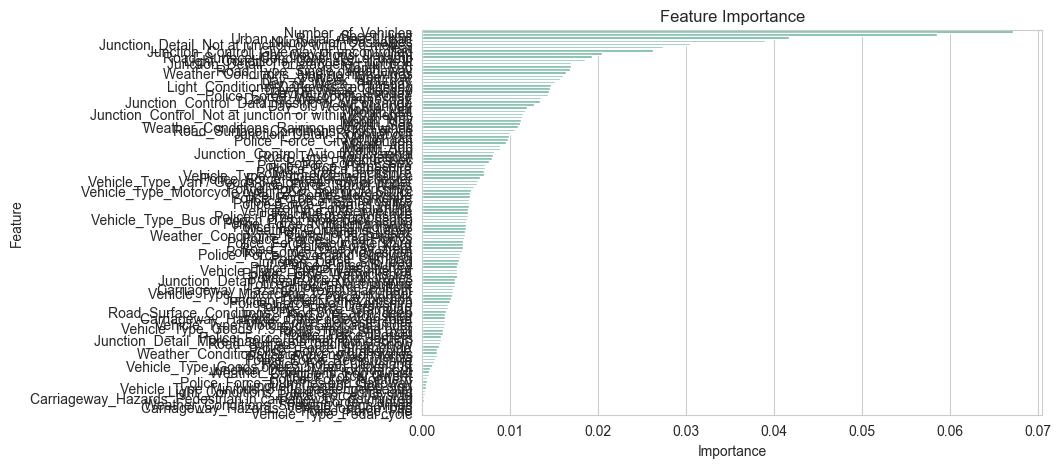

In [27]:
sns.barplot(x="Importance", y="Feature", data=importance_df)

plt.title("Feature Importance")

plt.show()

21 Final Result

In [28]:
# -------------------------------
# Point 21 : Final Result
# -------------------------------

from sklearn.metrics import accuracy_score

# Calculate accuracies
log_accuracy = accuracy_score(y_test, log_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)
rf_accuracy = accuracy_score(y_test, rf_pred)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("Logistic Regression Accuracy:", log_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)
print("KNN Accuracy:", knn_accuracy)

# Store models in dictionary
models = {
    "Logistic Regression": log_accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy,
    "KNN": knn_accuracy
}

# Find best model
best_model = max(models, key=models.get)

print("\nBest Model:", best_model)
print("Best Accuracy:", models[best_model])

Logistic Regression Accuracy: 0.851
Decision Tree Accuracy: 0.8416666666666667
Random Forest Accuracy: 0.6708333333333333
KNN Accuracy: 0.7611666666666667

Best Model: Logistic Regression
Best Accuracy: 0.851


Testing 

In [29]:
import joblib
joblib.dump(rf_model, "rf_model.pkl")

joblib.dump(log_model, "log_model.pkl")

['log_model.pkl']

Evaluating the Model Prediction

In [30]:
# -------------------------------
# Final User Input Prediction System
# -------------------------------

import pandas as pd
import joblib

# -------------------------------
# Load trained model
# -------------------------------
rf_model = joblib.load("rf_model.pkl")

# -------------------------------
# Take user input
# -------------------------------
month = input("Enter Month (jan/feb/mar...): ").lower()
speed = int(input("Enter Speed Limit: "))
vehicles = int(input("Enter Number of Vehicles: "))
casualties = int(input("Enter Number of Casualties: "))

# -------------------------------
# Create full feature row (121 features)
# -------------------------------
new_data = pd.DataFrame(columns=X_train.columns)
new_data.loc[0] = 0

# -------------------------------
# Set important features
# -------------------------------

# Month (One-Hot Encoding)
month_col = "Month_" + month.capitalize()
if month_col in new_data.columns:
    new_data[month_col] = 1
else:
    print("⚠️ Invalid month entered! Using default (Jan).")
    new_data["Month_Jan"] = 1

# Numerical features
new_data["Speed_limit"] = speed
new_data["Number_of_Vehicles"] = vehicles
new_data["Number_of_Casualties"] = casualties

# Default Year
if "Year" in new_data.columns:
    new_data["Year"] = 2020

# -------------------------------
# Prediction
# -------------------------------
prediction = rf_model.predict(new_data)[0]

# Map to readable output
label_map = {
    "Slight": "Low Severity",
    "Serious": "Medium Severity",
    "Fatal": "High Severity"
}
print("\nPrediction (Model Output):", prediction)
print("Accident Severity:", label_map.get(prediction, prediction))


Prediction (Model Output): Slight
Accident Severity: Low Severity


Dashboard

In [31]:
import subprocess
import tempfile

app_code = """
import streamlit as st
import pandas as pd
import joblib

# ------------------ PAGE CONFIG ------------------
st.set_page_config(page_title="Traffic Dashboard", layout="wide")

# ------------------ CUSTOM UI ------------------
st.markdown(\"\"\"
<style>
.stApp {
    background: linear-gradient(to right, #1e3c72, #2a5298);
    color: white;
}
h1, h2, h3 {
    color: #ffdd57;
}
</style>
\"\"\", unsafe_allow_html=True)

# ------------------ LOAD DATA ------------------
data = pd.read_csv("Road Accident Data.csv")

# ------------------ CREATE MONTH COLUMN ------------------
if 'Accident_Date' in data.columns:
    data['Accident_Date'] = pd.to_datetime(data['Accident_Date'], errors='coerce')
    data['Month'] = data['Accident_Date'].dt.month_name()

# ------------------ LOAD LOGISTIC MODEL ------------------
model = joblib.load("log_model.pkl")   # 🔥 changed here

# ------------------ TITLE ------------------
st.title("🚦 Traffic Accident Dashboard")

# ------------------ SIDEBAR ------------------
st.sidebar.header("🔍 Filters")

year = st.sidebar.selectbox("Year", sorted(data['Year'].dropna().unique()))
weather = st.sidebar.selectbox("Weather", data['Weather_Conditions'].dropna().unique())

# Month filter
if 'Month' in data.columns:
    month = st.sidebar.selectbox("Month", sorted(data['Month'].dropna().unique()))
    filtered = data[
        (data['Year'] == year) &
        (data['Weather_Conditions'] == weather) &
        (data['Month'] == month)
    ]
else:
    filtered = data[
        (data['Year'] == year) &
        (data['Weather_Conditions'] == weather)
    ]

# ------------------ METRICS ------------------
st.markdown("## 📊 Overview")

col1, col2, col3 = st.columns(3)

col1.metric("🚗 Total Accidents", len(filtered))
col2.metric("💥 Casualties", int(filtered['Number_of_Casualties'].sum()) if len(filtered)>0 else 0)
col3.metric("🚙 Vehicles", int(filtered['Number_of_Vehicles'].sum()) if len(filtered)>0 else 0)

# ------------------ CHART ------------------
st.markdown("## 📈 Accident Severity")

if len(filtered) > 0:
    st.bar_chart(filtered['Accident_Severity'].value_counts())
else:
    st.warning("No data available for selected filters")

# ------------------ EXTRA CHART ------------------
st.markdown("## 📅 Accidents by Day")

if len(filtered) > 0:
    st.bar_chart(filtered['Day_of_Week'].value_counts())
else:
    st.warning("No data available")

# ------------------ MODEL INFO ------------------
st.markdown("## 🤖 Model Information")

st.success("Algorithm Used: Logistic Regression")
st.write("Best performing model with highest accuracy")

# ------------------ PREDICTION INFO ------------------
st.markdown("## 🔮 Prediction")

st.warning("⚠️ Prediction disabled: Model requires full feature input after preprocessing.")
"""

# ------------------ CREATE TEMP FILE ------------------
with tempfile.NamedTemporaryFile(delete=False, suffix=".py") as f:
    f.write(app_code.encode())
    temp_file = f.name

# ------------------ RUN STREAMLIT ------------------
subprocess.Popen(["streamlit", "run", temp_file])

<Popen: returncode: None args: ['streamlit', 'run', 'C:\\Users\\HP\\AppData\...>

Conclusion:

In this project, a road accident dataset was analyzed to predict accident severity using machine learning techniques.

Three models were trained:
1. Logistic Regression
2. Decision Tree
3. Random Forest

After training and evaluation, Logistic Regression achieved the highest accuracy on the dataset.

Key insights:
- Weather conditions and road surface significantly influence accidents.
- Speed limits and vehicle type also affect accident severity.

This project demonstrates how machine learning can be used to analyze traffic accident data and help in improving road safety.
### **Conclusion**


* Data preprocessing was performed, including handling missing values and encoding categorical variables.
* Exploratory Data Analysis (EDA) showed that weather conditions, road surface, time, and vehicle attributes significantly influence accidents.
* **Logistic Regression achieved the highest accuracy**, making it the best-performing model for this dataset.
* An interactive dashboard was developed using Streamlit to visualize accident trends based on year, weather, and month.

Overall, the project demonstrates how machine learning and data visualization can be effectively used to analyze traffic accident data and support better decision-making for road safety.
